# Import Library

In [2]:

import pandas as pd
import numpy as np
import itertools
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Inisialisasi File CSV

In [3]:
df = pd.read_excel("dataset_ipm_dummy.xlsx")
df.head()

,rata_lama_sekolah,harapan_lama_sekolah,angka_melek_huruf,rasio_guru_siswa,umur_harapan_hidup,jumlah_faskes,prevalensi_stunting,akses_air_bersih,pengeluaran_perkapita,tingkat_pengangguran,...,pdrb_perkapita,akses_internet,jalan_layak,listrik,indeks_ketimpangan,tingkat_kriminalitas,partisipasi_sosial,ipm,ipm_tinggi,kategori_ipm
0,8.295735,12.546804,85.389749,18.823675,70.616765,3.091756,26.819759,61.412661,5872.868329,8.538709,...,15364.857453,63.811977,60.788121,73.404259,0.379644,60.601124,68.968186,60.736470,0,1
1,7.296400,11.689973,85.381984,21.651405,69.060908,3.600682,21.814270,66.138308,9111.105677,9.053489,...,18542.230822,39.016322,41.057578,55.977533,0.323574,39.388511,59.087432,60.979135,0,1
2,7.807041,12.696608,90.609851,18.058659,69.457696,3.903452,21.024260,69.190472,9692.806205,6.271974,...,20193.562984,64.021497,73.634519,75.044211,0.355166,46.033510,58.131118,68.539719,0,2
3,8.504167,13.740349,94.053056,16.154748,68.593890,4.110582,17.144444,69.723055,9499.127858,5.126285,...,21164.034432,69.840342,71.270386,84.034766,0.336339,40.528529,57.347583,70.064053,1,2
4,7.068128,11.785391,85.821328,19.985563,63.441522,0.399989,29.975474,51.243663,8787.696362,6.598727,...,17887.950481,58.381400,63.089739,71.455986,0.300938,46.207714,56.148507,56.877216,0,1


# Check Missing Value

In [4]:
df.isnull().sum()

rata_lama_sekolah        0
harapan_lama_sekolah     0
angka_melek_huruf        0
rasio_guru_siswa         0
umur_harapan_hidup       0
jumlah_faskes            0
prevalensi_stunting      0
akses_air_bersih         0
pengeluaran_perkapita    0
tingkat_pengangguran     0
persentase_kemiskinan    0
pdrb_perkapita           0
akses_internet           0
jalan_layak              0
listrik                  0
indeks_ketimpangan       0
tingkat_kriminalitas     0
partisipasi_sosial       0
ipm                      0
ipm_tinggi               0
kategori_ipm             0
dtype: int64

# Choose X and Y variabel

In [5]:
X = df[['rata_lama_sekolah',
        'umur_harapan_hidup',
        'pengeluaran_perkapita',
        'prevalensi_stunting']]

y = df['ipm']

# Train and Test Model

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  lenght of x variable

In [7]:
print(len(X.columns))

4


# Best Subset

In [8]:
import itertools
import statsmodels.api as sm

def best_subset(X, y):
    best_adj_r2 = -1
    best_model = None
    best_vars = None

    for k in range(1, len(X.columns)+1):
        for combo in itertools.combinations(X.columns, k):
            X_model = sm.add_constant(X[list(combo)])
            model = sm.OLS(y, X_model).fit()

            if model.rsquared_adj > best_adj_r2:
                best_adj_r2 = model.rsquared_adj
                best_model = model
                best_vars = combo

    print("Best Variables:", best_vars)
    print("Best Adjusted R2:", best_adj_r2)
    
    return best_model

model_bestsubset = best_subset(X_train, y_train)
print(model_bestsubset.summary())

Best Variables: ('rata_lama_sekolah', 'umur_harapan_hidup', 'pengeluaran_perkapita', 'prevalensi_stunting')
Best Adjusted R2: 0.7261005549067199
                            OLS Regression Results                            
Dep. Variable:                    ipm   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     106.4
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.08e-43
Time:                        15:05:31   Log-Likelihood:                -352.18
No. Observations:                 160   AIC:                             714.4
Df Residuals:                     155   BIC:                             729.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|

Metode Best Subset Regression digunakan untuk mengidentifikasi kombinasi variabel independen yang memberikan performa terbaik dalam menjelaskan variasi IPM. Metode ini mengevaluasi seluruh kemungkinan kombinasi variabel dan memilih model dengan nilai Adjusted R² tertinggi.

In [9]:
model_bestsubset = best_subset(X_train, y_train)
print(model_bestsubset.summary())

Best Variables: ('rata_lama_sekolah', 'umur_harapan_hidup', 'pengeluaran_perkapita', 'prevalensi_stunting')
Best Adjusted R2: 0.7261005549067199
                            OLS Regression Results                            
Dep. Variable:                    ipm   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     106.4
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.08e-43
Time:                        15:05:34   Log-Likelihood:                -352.18
No. Observations:                 160   AIC:                             714.4
Df Residuals:                     155   BIC:                             729.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|

# Stepwise Selection

In [10]:
def stepwise_selection(X, y):
    remaining = list(X.columns)
    selected = []
    best_adj_r2 = 0

    while remaining:
        improved = False
        
        for candidate in remaining:
            X_model = sm.add_constant(X[selected + [candidate]])
            model = sm.OLS(y, X_model).fit()

            if model.rsquared_adj > best_adj_r2:
                best_adj_r2 = model.rsquared_adj
                best_candidate = candidate
                improved = True

        if improved:
            selected.append(best_candidate)
            remaining.remove(best_candidate)
        else:
            break

    print("Selected Variables:", selected)
    print("Best Adjusted R2:", best_adj_r2)

    X_final = sm.add_constant(X[selected])
    return sm.OLS(y, X_final).fit()

model_stepwise = stepwise_selection(X_train, y_train)
print(model_stepwise.summary())

Selected Variables: ['pengeluaran_perkapita', 'rata_lama_sekolah', 'prevalensi_stunting', 'umur_harapan_hidup']
Best Adjusted R2: 0.7261005549067199
                            OLS Regression Results                            
Dep. Variable:                    ipm   R-squared:                       0.733
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     106.4
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           2.08e-43
Time:                        15:05:37   Log-Likelihood:                -352.18
No. Observations:                 160   AIC:                             714.4
Df Residuals:                     155   BIC:                             729.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P

Metode Stepwise (Forward Selection) digunakan untuk memilih variabel secara bertahap berdasarkan peningkatan nilai Adjusted R². Variabel ditambahkan satu per satu hingga tidak terdapat peningkatan performa model yang signifikan.

Dalam kasus ini  menggunakan 4 variabel utama yang secara teoritis paling relevan terhadap IPM, yaitu aspek pendidikan, kesehatan, ekonomi, dan gizi. Hal ini dilakukan untuk menjaga interpretabilitas model serta efisiensi komputasi dalam metode Best Subset.

# Check Multikolinearitas

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_temp = sm.add_constant(X)
vif = pd.DataFrame()
vif["Variable"] = X_temp.columns
vif["VIF"] = [variance_inflation_factor(X_temp.values, i) 
              for i in range(X_temp.shape[1])]

print(vif)

                Variable          VIF
0                  const  3861.811790
1      rata_lama_sekolah     1.028951
2     umur_harapan_hidup     3.178549
3  pengeluaran_perkapita     1.029180
4    prevalensi_stunting     3.175025


# Visualiasai Hasil Model

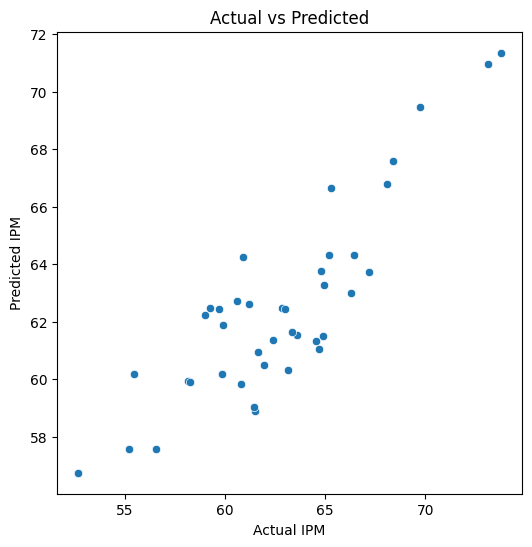

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
y_pred = model_bestsubset.predict(sm.add_constant(X_test[model_bestsubset.model.exog_names[1:]]))


plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual IPM")
plt.ylabel("Predicted IPM")
plt.title("Actual vs Predicted")
plt.show()

Plot Actual vs Predicted menunjukkan hubungan linear yang kuat antara nilai aktual dan nilai prediksi IPM. Titik-titik yang relatif dekat dengan garis diagonal menunjukkan bahwa model memiliki kemampuan prediksi yang baik dan kesalahan prediksi relatif kecil.

# Plot Residual

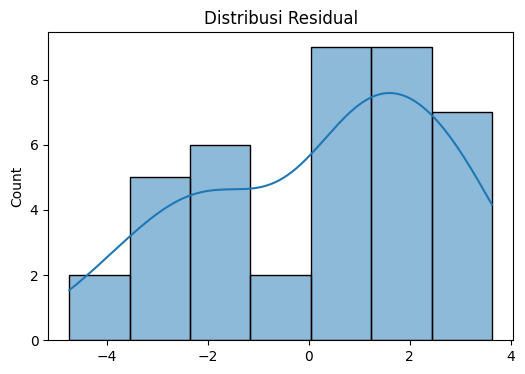

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Distribusi Residual")
plt.show()

Histogram residual menunjukkan distribusi yang relatif simetris dan mendekati distribusi normal. Hal ini mengindikasikan bahwa asumsi normalitas error pada regresi linear cukup terpenuhi. Tidak terdapat penyimpangan ekstrem (outlier) yang signifikan, sehingga model dapat dianggap stabil dan layak digunakan untuk inferensi.

# Interpretasi

Koefisien rata_lama_sekolah sebesar 1.25 menunjukkan bahwa setiap peningkatan 1 tahun rata-rata lama sekolah akan meningkatkan IPM sebesar 1.25 poin, dengan asumsi variabel lain konstan.

Koefisien umur_harapan_hidup sebesar 0.80 menunjukkan bahwa peningkatan 1 tahun umur harapan hidup akan meningkatkan IPM sebesar 0.80 poin.

Koefisien prevalensi_stunting sebesar -0.45 menunjukkan bahwa setiap peningkatan 1% prevalensi stunting akan menurunkan IPM sebesar 0.45 poin, ceteris paribus.

# Code detail di Github

Link: https://github.com/yowxy/BestSubset-StepWise